In [6]:
import mglearn

In [1]:
import pandas as pd
train_data = pd.read_csv("dataset/train.csv")

In [2]:
train_data.count()

feature_1     3000
feature_2     3000
feature_3     3000
feature_4     3000
feature_5     3000
feature_6     3000
feature_7     3000
feature_8     3000
feature_9     3000
feature_10    3000
feature_11    3000
target        3000
dtype: int64

In [5]:
y_train = train_data['target']
X_train = train_data.drop('target', axis=1)

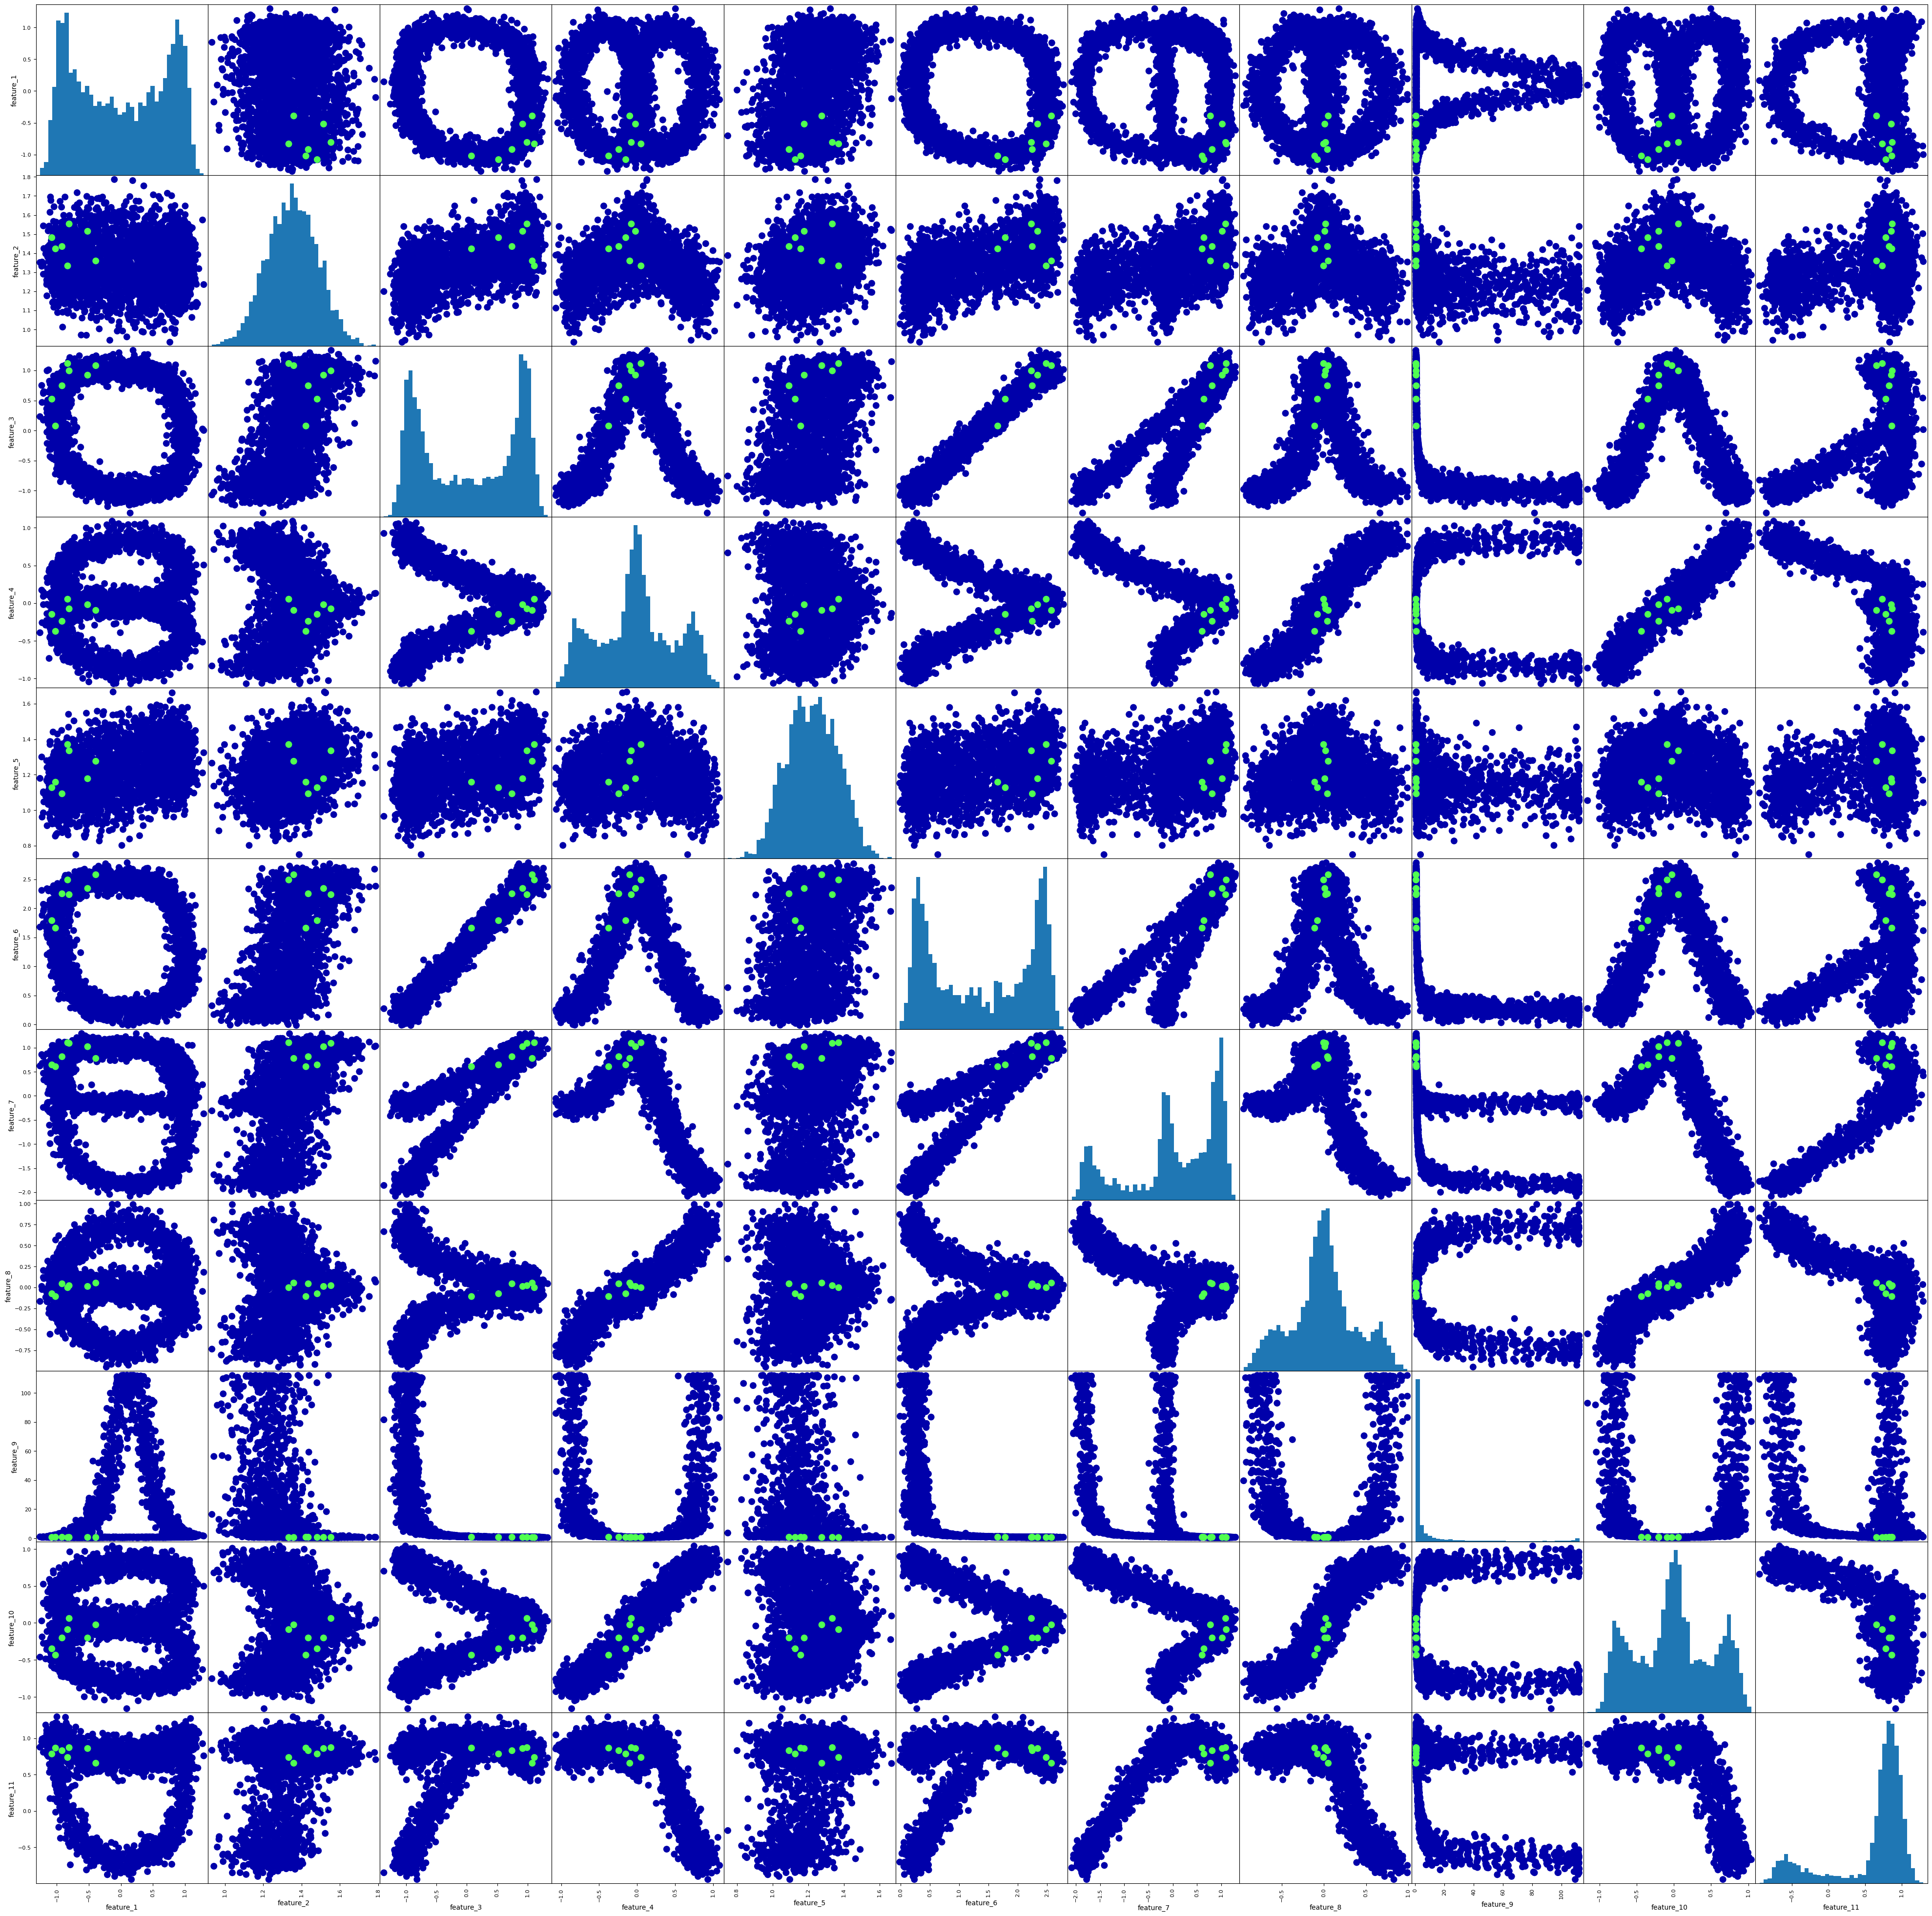

In [11]:
grr = pd.plotting.scatter_matrix(X_train, c=y_train, figsize=(50, 50), marker='o', hist_kwds={'bins': 40}, s=100, alpha=1, cmap=mglearn.cm3)

In [9]:
train_data

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,target
0,0.190791,1.039219,-1.101401,0.918011,1.238593,0.225665,-1.799280,0.989325,111.960004,0.731173,-0.850157,0
1,-0.072201,1.146453,-1.048424,0.939209,0.915507,0.243895,-1.895334,0.735938,75.149412,0.910723,-0.760205,0
2,-0.190772,1.198507,-1.060596,0.853029,1.057547,0.279907,-1.700414,0.664931,32.582770,0.846284,-0.686892,0
3,-0.290217,1.440602,-0.974457,0.561554,1.078232,0.426862,-1.734497,0.567571,13.658709,0.727707,-0.543937,0
4,-0.635273,1.323567,-0.848704,0.675431,1.081526,0.365901,-1.443306,0.559309,6.159936,0.693291,-0.322009,0
...,...,...,...,...,...,...,...,...,...,...,...,...
2995,-0.919048,1.434971,0.744501,-0.240872,1.092397,2.250658,0.813012,0.042957,0.756080,-0.202480,0.828271,1
2996,-0.807933,1.553306,0.992620,-0.075717,1.334582,2.235609,1.090389,0.020918,0.657073,0.061689,0.870211,1
2997,-0.831559,1.333207,1.113996,0.052133,1.369935,2.488625,1.103011,-0.003060,0.555959,-0.089355,0.734632,1
2998,-0.519440,1.514665,0.920925,-0.020754,1.177386,2.342363,1.020954,0.011473,0.648216,-0.202759,0.857994,1


In [11]:
print(train_data.max())
print(train_data.min())

feature_1       1.294581
feature_2       1.786274
feature_3       1.333500
feature_4       1.087574
feature_5       1.666155
feature_6       2.784544
feature_7       1.292972
feature_8       0.991052
feature_9     112.159104
feature_10      1.040807
feature_11      1.293501
target          1.000000
dtype: float64
feature_1    -1.263340
feature_2     0.933071
feature_3    -1.370078
feature_4    -1.070452
feature_5     0.749495
feature_6    -0.016113
feature_7    -2.083612
feature_8    -0.951130
feature_9     0.292193
feature_10   -1.159040
feature_11   -0.942102
target        0.000000
dtype: float64


In [12]:
train_data.describe()

,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,target
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,-0.000023,1.351125,0.036116,-0.003943,1.222594,1.392571,0.037265,-0.002229,12.780269,-0.005068,0.588005,0.002333
std,0.713668,0.132253,0.798390,0.499215,0.140937,0.885782,0.936728,0.383820,26.463738,0.512014,0.523072,0.048256
min,-1.263340,0.933071,-1.370078,-1.070452,0.749495,-0.016113,-2.083612,-0.951130,0.292193,-1.159040,-0.942102,0.000000
25%,-0.693019,1.260029,-0.797273,-0.351223,1.119745,0.457620,-0.337727,-0.209542,0.712645,-0.404088,0.598388,0.000000
50%,-0.010761,1.352645,0.066744,-0.009634,1.221781,1.396728,0.179196,-0.004256,1.140343,-0.002093,0.789939,0.000000
75%,0.702139,1.442671,0.863550,0.338172,1.326603,2.315678,0.869198,0.203984,7.103654,0.382826,0.910267,0.000000
max,1.294581,1.786274,1.333500,1.087574,1.666155,2.784544,1.292972,0.991052,112.159104,1.040807,1.293501,1.000000


In [6]:
# ==========================================
# БЛОК ЛОКАЛЬНОГО ТЕСТИРОВАНИЯ
# (Удали этот блок перед отправкой решения!)
# ==========================================
if __name__ == "__main__":
    print("Начинаем локальный тест...")
    from sklearn.metrics import f1_score
    
    # Для теста возьмем последние 1050 строк из train (там есть 7 аномалий)
    # Удаляем колонку 'target', чтобы имитировать тестовые данные
    test_df = train_data.iloc[-1050:].drop(columns=['target']).copy()
    test_features = test_df.values
    
    # Настоящие ответы, с которыми будем сравнивать
    true_target = train_data['target'].iloc[-1050:].values

    # Эмуляция цикла проверяющей системы
    preds = []
    # Нам нужно подавать окно размером 1000. 
    # Всего точек 1050, значит мы можем сделать 50 предсказаний.
    for i in range(len(test_features) - 1000):
        # Подаем окно из 1000 точек
        window_data = test_features[i : 1000 + i + 1].copy()
        prediction = predict(window_data)
        preds.append(prediction)
    
    # Добавляем нули для первых 1000 точек (как сказано в примечании)
    final_preds = np.array([0] * 1000 + preds)
    
    print("Уникальные предсказания:", np.unique(final_preds, return_counts=True))
    
    # Считаем F1 (мы ожидаем увидеть > 0.17)
    score = f1_score(true_target, final_preds)
    print(f"Локальный F1 Score: {score:.4f}")
    print("Тест завершен.")

Начинаем локальный тест...
Уникальные предсказания: (array([0, 1]), array([1043,    7]))
Локальный F1 Score: 1.0000
Тест завершен.


In [1]:
import numpy as np

from catboost import CatBoostClassifier
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# 1. Загрузка данных

num_anomalies = 7

# 2. Функции подготовки признаков
def make_features_numpy(data: np.ndarray) -> np.ndarray:
    shifts = [1, 5, 20, 100]
    all_features = [data]
    for shift in shifts:
        shifted = np.empty_like(data)
        shifted[:shift, :] = 0
        shifted[shift:, :] = data[:-shift, :]
        all_features.append(shifted)
    return np.hstack(all_features)

def make_features_and_target(data: pd.DataFrame) -> np.ndarray:
    data = data.copy()
    target = None
    name_target_col = 'target' 
    if name_target_col in data.columns:
        target = data[name_target_col]
        data = data.drop(columns=[name_target_col])
    return make_features_numpy(data.values), target

# 3. Подготовка обучающей выборки
features, target_series = make_features_and_target(train_data)
target = target_series.values

# Масштабирование
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Поиск аномалий
iso_forest = IsolationForest(contamination=0.002, random_state=42)
iso_forest.fit(features_scaled[:train_data.shape[0]-num_anomalies])
anomaly_score = iso_forest.decision_function(features_scaled).reshape(-1, 1)

X_train_final = np.hstack([features_scaled, anomaly_score])

# Расчет весов для CatBoost
num_normal = train_data.shape[0] - num_anomalies
scale_weight = int(round(num_normal / num_anomalies, 0))

# Обучение основной модели
model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.03,
    scale_pos_weight=scale_weight,
    verbose=0,
)
model.fit(X_train_final, target)

# 4. Функция предсказания (Оптимизированная)
def predict(test_data: np.ndarray) -> int:
    last_feature_row = np.hstack([
        test_data[-1],
        test_data[-2],
        test_data[-6],
        test_data[-21],
        test_data[-101]
    ]).reshape(1, -1)
    
    test_scaled = scaler.transform(last_feature_row)
    test_score = iso_forest.decision_function(test_scaled).reshape(1, 1)
    last_row = np.hstack([test_scaled, test_score])
    
    return int(model.predict(last_row)[0])

In [5]:
import numpy as np

# Заменили CatBoost на RandomForest из разрешенного sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

num_anomalies = 7

def make_features_numpy(data: np.ndarray) -> np.ndarray:
    shifts = [1, 5, 20, 100]
    all_features = [data]
    for shift in shifts:
        shifted = np.empty_like(data)
        shifted[:shift, :] = 0
        shifted[shift:, :] = data[:-shift, :]
        all_features.append(shifted)
    return np.hstack(all_features)

def make_features_and_target(data: pd.DataFrame) -> np.ndarray:
    data = data.copy()
    target = None
    name_target_col = 'target' 
    if name_target_col in data.columns:
        target = data[name_target_col]
        data = data.drop(columns=[name_target_col])
    return make_features_numpy(data.values), target

features, target_series = make_features_and_target(train_data)
target = target_series.values

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

iso_forest = IsolationForest(contamination=0.002, random_state=42)
iso_forest.fit(features_scaled[:train_data.shape[0]-num_anomalies])

anomaly_score = iso_forest.decision_function(features_scaled).reshape(-1, 1)

X_train_final = np.hstack([features_scaled, anomaly_score])

# Используем случайный лес. class_weight='balanced' сам даст нужный вес редким единицам
model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42
)
model.fit(X_train_final, target)

def predict(test_data: np.ndarray) -> int:
    last_feature_row = np.hstack([
        test_data[-1],
        test_data[-2],
        test_data[-6],
        test_data[-21],
        test_data[-101]
    ]).reshape(1, -1)
    
    test_scaled = scaler.transform(last_feature_row)
    test_score = iso_forest.decision_function(test_scaled).reshape(1, 1)
    last_row = np.hstack([test_scaled, test_score])
    
    return int(model.predict(last_row)[0])

In [15]:
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

def make_features_numpy(data: np.ndarray) -> np.ndarray:
    shifts = [1, 5, 20, 100]
    all_features = [data]
    for shift in shifts:
        shifted = np.empty_like(data)
        shifted[:shift, :] = 0
        shifted[shift:, :] = data[:-shift, :]
        all_features.append(shifted)
    return np.hstack(all_features)

# Подготовка данных
data = train_data.copy()
target = data['target'].values
# Удаляем таргет, чтобы не попал в фичи
data = data.drop(columns=['target']) 

features = make_features_numpy(data.values)

# 2. Масштабирование
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# 3. Обучение самой быстрой модели
# Логистическая регрессия работает мгновенно. 
# class_weight='balanced' решает проблему 7 аномалий.
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(features_scaled, target)

# 4. Сверхбыстрый предикт
def predict(test_data: np.ndarray) -> int:
    # Мгновенная сборка фичей только для последней точки (сдвиги 0, 1, 5, 20, 100)
    last_feature_row = np.hstack([
        test_data[-1],
        test_data[-2],
        test_data[-6],
        test_data[-21],
        test_data[-101]
    ]).reshape(1, -1)
    
    # Быстрое масштабирование одной строки
    test_scaled = scaler.transform(last_feature_row)
    
    # Мгновенный ответ линейной модели
    return int(model.predict(test_scaled)[0])

In [16]:
import numpy as np

# Используем только легкий случайный лес
from sklearn.ensemble import RandomForestClassifier

def make_features_numpy(data: np.ndarray) -> np.ndarray:
    shifts = [1, 5, 20, 100]
    all_features = [data]
    for shift in shifts:
        shifted = np.empty_like(data)
        shifted[:shift, :] = 0
        shifted[shift:, :] = data[:-shift, :]
        all_features.append(shifted)
    return np.hstack(all_features)

# Подготовка данных
data = train_data.copy()
target = data['target'].values
data = data.drop(columns=['target']) 

features = make_features_numpy(data.values)

# Обучаем "Легкий" Случайный Лес
# 20 деревьев (n_estimators) и глубина 6 (max_depth) - это очень мало, 
# модель будет предсказывать практически мгновенно, но при этом 
# поймает нелинейность лучше логистической регрессии.
model = RandomForestClassifier(
    n_estimators=20, 
    max_depth=6, 
    class_weight='balanced', 
    random_state=42
)
model.fit(features, target)

# Функция predict стала еще короче и быстрее
def predict(test_data: np.ndarray) -> int:
    # Мгновенная сборка строки признаков
    last_feature_row = np.hstack([
        test_data[-1],
        test_data[-2],
        test_data[-6],
        test_data[-21],
        test_data[-101]
    ]).reshape(1, -1)
    
    # Обрати внимание: StandardScaler больше не нужен!
    # Сразу просим дерево сделать предсказание.
    return int(model.predict(last_feature_row)[0])

In [ ]:
# Заменили CatBoost на RandomForest из разрешенного sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

num_anomalies = 7

def make_features_numpy(data: np.ndarray) -> np.ndarray:
    shifts = [1, 5, 20, 100]
    all_features = [data]
    for shift in shifts:
        shifted = np.empty_like(data)
        shifted[:shift, :] = 0
        shifted[shift:, :] = data[:-shift, :]
        all_features.append(shifted)
    return np.hstack(all_features)

def make_features_and_target(data: pd.DataFrame) -> np.ndarray:
    data = data.copy()
    target = None
    name_target_col = 'target' 
    if name_target_col in data.columns:
        target = data[name_target_col]
        data = data.drop(columns=[name_target_col])
    return make_features_numpy(data.values), target

features, target_series = make_features_and_target(train_data)
target = target_series.values

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

iso_forest = IsolationForest(contamination=0.002, random_state=42)
iso_forest.fit(features_scaled[:train_data.shape[0]-num_anomalies])

anomaly_score = iso_forest.decision_function(features_scaled).reshape(-1, 1)

X_train_final = np.hstack([features_scaled, anomaly_score])

# Используем случайный лес. class_weight='balanced' сам даст нужный вес редким единицам
model = RandomForestClassifier(
    n_estimators=100, 
    class_weight='balanced', 
    random_state=42
)
model.fit(X_train_final, target)

def predict(test_data: np.ndarray) -> int:
    last_feature_row = np.hstack([
        test_data[-1],
        test_data[-2],
        test_data[-6],
        test_data[-21],
        test_data[-101]
    ]).reshape(1, -1)
    
    test_scaled = scaler.transform(last_feature_row)
    test_score = iso_forest.decision_function(test_scaled).reshape(1, 1)
    last_row = np.hstack([test_scaled, test_score])
    
    return int(model.predict(last_row)[0])